### Important: scikit-learn does not have a function named ID3. We can implement an ID3-style decision tree using DecisionTreeClassifier(criterion="entropy"), because ID3 selects splits using Information Gain based on entropy.

### Import the required libraries

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt


**Explanation** 

* pandas → used to read and manipulate the CSV file.

* train_test_split → divides data into training and testing sets.

* DecisionTreeClassifier → creates the decision tree.

* accuracy_score → calculates prediction accuracy.

* confusion_matrix → shows correct and incorrect predictions.

* classification_report → gives precision, recall, and F1-score.

* LabelEncoder → converts text categories such as Sunny and Rain into numbers.

* plot_tree → displays the decision tree.

* matplotlib → used for visualization.

### Load the weather.csv file

In [2]:
df = pd.read_csv("weather.csv")

print(df)


     Outlook Temperature Humidity  Windy Play
0      Sunny         Hot     High  False   No
1      Sunny         Hot     High   True   No
2   Overcast         Hot     High  False  Yes
3       Rain        Mild     High  False  Yes
4       Rain        Cool   Normal  False  Yes
5       Rain        Cool   Normal   True   No
6   Overcast        Cool   Normal   True  Yes
7      Sunny        Mild     High  False   No
8      Sunny        Cool   Normal  False  Yes
9       Rain        Mild   Normal  False  Yes
10     Sunny        Mild   Normal   True  Yes
11  Overcast        Mild     High   True  Yes
12  Overcast         Hot   Normal  False  Yes
13      Rain        Mild     High   True   No


### Separate input and output

In [3]:
X_features = df.drop("Play", axis=1)
y_target = df["Play"]


### Convert categorical values into numbers

In [4]:
encoders = {}

for column in X_features.columns:
    le = LabelEncoder()
    X_features[column] = le.fit_transform(X_features[column])
    encoders[column] = le

target_encoder = LabelEncoder()
y_target = target_encoder.fit_transform(y_target)


Overcast → 0


Rain     → 1

Sunny    → 2

No  → 0

Yes → 1

In [5]:
print(X_features)
print(y_target)


    Outlook  Temperature  Humidity  Windy
0         2            1         0      0
1         2            1         0      1
2         0            1         0      0
3         1            2         0      0
4         1            0         1      0
5         1            0         1      1
6         0            0         1      1
7         2            2         0      0
8         2            0         1      0
9         1            2         1      0
10        2            2         1      1
11        0            2         0      1
12        0            1         1      0
13        1            2         0      1
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


### Split the dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=42
)


### Create the ID3-style Decision Tree

In [7]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


### Why criterion="entropy"?
**ID3 uses Entropy and Information Gain to select the best attribute.**

    Entropy → measures impurity
               ↓
    Information Gain → measures usefulness of a split
               ↓
    Choose attribute with highest Information Gain


**criterion="entropy"**

makes the scikit-learn tree use entropy-based splitting.

Strictly speaking, this is an ID3-style tree, not a complete textbook implementation of every ID3 detail.

### Train the model

In [8]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Make predictions

In [9]:
y_pred = model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:   ", y_test)


Predicted: [1 1 0]
Actual:    [1 1 0]


Play = Yes = 1

or

Play = No = 0

### Calculate accuracy

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")


Accuracy: 1.0
Accuracy percentage: 100.0 %


### Display the confusion matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1 0]
 [0 2]]


| <font size="3"></font> | <font size="3">Predicted</font> |<font size="3">Predicted</font> |  
| :--- | ---: | ---: |
| <font size="3"></font>  | <font size="3">No</font> | <font size="3">Yes</font> |
|  <font size="3">Actuan No</font> | <font size="3">TN</font> | <font size="3">FP</font> |
|  <font size="3">Actuan Yes</font> | <font size="3">FN</font> | <font size="3">TP</font> |  
 
 
 | <font size="3"></font> | <font size="3">Predicted</font> |<font size="3">Predicted</font> |  
| :--- | ---: | ---: |
| <font size="3"></font>  | <font size="3">No</font> | <font size="3">Yes</font> |
|  <font size="3">Actuan No 0</font> | <font size="3">1</font> | <font size="3">0</font> |
|  <font size="3">Actuan Yes 1</font> | <font size="3">0</font> | <font size="3">2</font> |

### Classification report

In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))


              precision    recall  f1-score   support

          No       1.00      1.00      1.00         1
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Visualize the decision tree

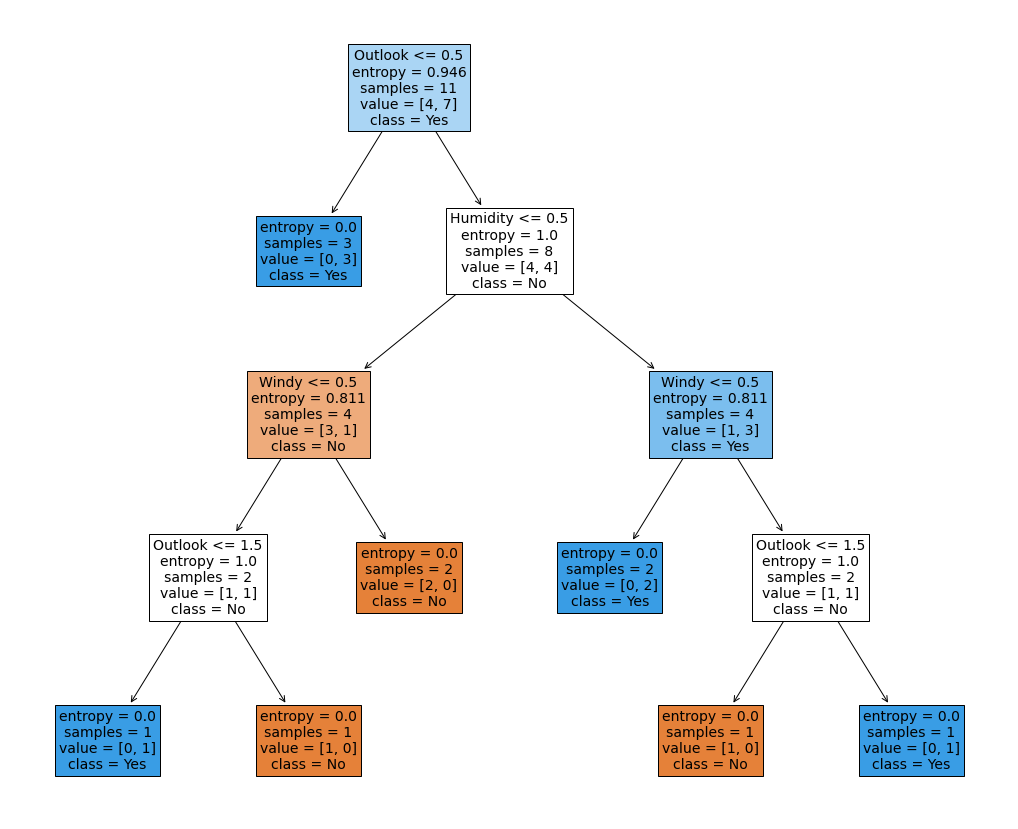

In [13]:
plt.figure(figsize=(18, 15))

plot_tree(
    model,
    feature_names=X_features.columns,
    class_names=target_encoder.classes_,
    filled=True,
    fontsize=14
)

plt.show()


### Complete program

Dataset:
     Outlook Temperature Humidity  Windy Play
0      Sunny         Hot     High  False   No
1      Sunny         Hot     High   True   No
2   Overcast         Hot     High  False  Yes
3       Rain        Mild     High  False  Yes
4       Rain        Cool   Normal  False  Yes
5       Rain        Cool   Normal   True   No
6   Overcast        Cool   Normal   True  Yes
7      Sunny        Mild     High  False   No
8      Sunny        Cool   Normal  False  Yes
9       Rain        Mild   Normal  False  Yes
10     Sunny        Mild   Normal   True  Yes
11  Overcast        Mild     High   True  Yes
12  Overcast         Hot   Normal  False  Yes
13      Rain        Mild     High   True   No

First five records:
    Outlook Temperature Humidity  Windy Play
0     Sunny         Hot     High  False   No
1     Sunny         Hot     High   True   No
2  Overcast         Hot     High  False  Yes
3      Rain        Mild     High  False  Yes
4      Rain        Cool   Normal  False  Yes

Encoded F

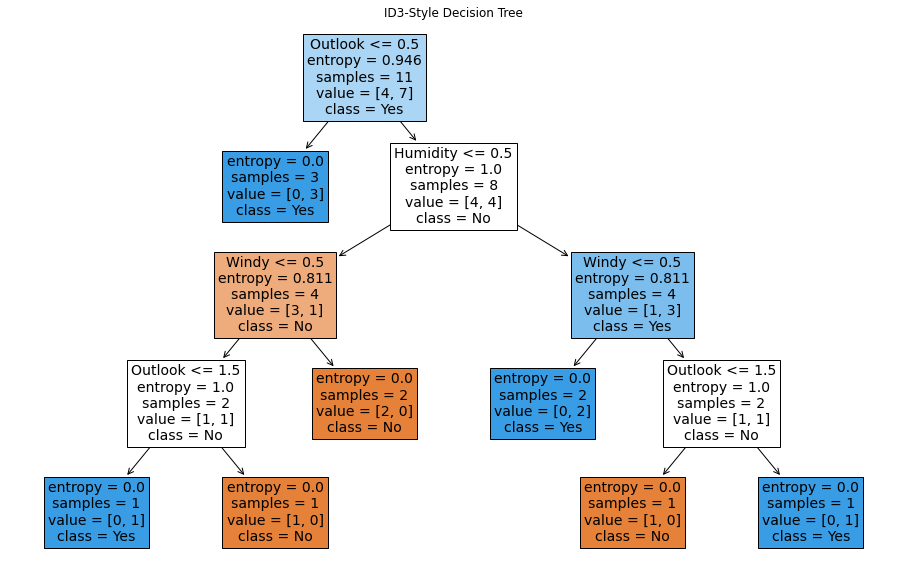

In [14]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt


# ---------------------------------
# Step 1: Read the dataset
# ---------------------------------

df = pd.read_csv("weather.csv")

print("Dataset:")
print(df)

print("\nFirst five records:")
print(df.head())


# ---------------------------------
# Step 2: Separate features
# and target
# ---------------------------------

X_features = df.drop("Play", axis=1)
y_target = df["Play"]


# ---------------------------------
# Step 3: Encode categorical data
# ---------------------------------

encoders = {}

for column in X_features.columns:
    le = LabelEncoder()
    X_features[column] = le.fit_transform(X_features[column])
    encoders[column] = le

target_encoder = LabelEncoder()
y_target = target_encoder.fit_transform(y_target)


print("\nEncoded Features:")
print(X_features)

print("\nEncoded Target:")
print(y_target)


# ---------------------------------
# Step 4: Split the dataset
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=42
)


# ---------------------------------
# Step 5: Create ID3-style tree
# ---------------------------------

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


# ---------------------------------
# Step 6: Train the model
# ---------------------------------

model.fit(X_train, y_train)


# ---------------------------------
# Step 7: Prediction
# ---------------------------------

y_pred = model.predict(X_test)

print("\nActual values:")
print(y_test)

print("\nPredicted values:")
print(y_pred)


# ---------------------------------
# Step 8: Accuracy
# ---------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")


# ---------------------------------
# Step 9: Confusion Matrix
# ---------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ---------------------------------
# Step 10: Classification Report
# ---------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)


# ---------------------------------
# Step 11: Display Decision Tree
# ---------------------------------

plt.figure(figsize=(16, 10))

plot_tree(
    model,
    feature_names=X_features.columns,
    class_names=target_encoder.classes_,
    filled=True,
    fontsize=14
)

plt.title("ID3-Style Decision Tree")
plt.show()
